In [2]:
# !pip install ahrs filterpy

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Part 1 -- The basic idea: combining two noisy guesses into one better guess

This is the whole idea behind a Kalman filter, stripped down to its simplest form: if you have two noisy measurements of the same thing, how do you combine them into a single, better estimate? Everything later in this notebook (tracking angles over time, tracking a moving object) is just this same trick, repeated every time step.

**1.1 Two sensors, one true value**

Imagine two thermometers reading the same CPU's temperature. Neither is perfect -- thermometer 1 is noisier than thermometer 2. If you just average them 50/50, you're wasting the fact that thermometer 2 is more trustworthy. The "correct" way to combine them gives more weight to whichever one is more precise:
$$K = \frac{\sigma_1^2}{\sigma_1^2+\sigma_2^2}, \qquad \text{fused estimate} = x_1 + K(x_2-x_1)$$
`K` (called the Kalman gain) is just "how much to move toward sensor 2." Below, we don't compute `K` by hand -- we let `filterpy.kalman.KalmanFilter` do it, and check that it lands on the same number as the formula.

In [5]:
from filterpy.kalman import KalmanFilter

np.random.seed(0)
sigma1, sigma2 = 3.0, 1.0          # sensor 1 is noisier than sensor 2
x1_single, x2_single = 58.0, 61.0  # one reading from each sensor

# a single measurement-fusion step (wide/uninformative prior -> P is not "used up" by anything yet)
kf1d = KalmanFilter(dim_x=1, dim_z=2)   # dim_x=1 state (the true value), dim_z=2 measurements (one per sensor)
kf1d.x = np.array([[0.0]])         # initial state guess (irrelevant here since P starts huge)
kf1d.F = np.array([[1.]])          # state-transition matrix -- static state, doesn't evolve on its own
kf1d.H = np.array([[1.], [1.]])    # observation matrix -- both sensors observe the same state
kf1d.P = np.array([[1e9]])         # initial state covariance -- uninformative prior
kf1d.R = np.diag([sigma1**2, sigma2**2])  # measurement noise covariance -- one variance per sensor
kf1d.Q = 0.                        # process noise covariance -- 0 because the true value is constant

kf1d.predict()
kf1d.update(np.array([[x1_single], [x2_single]]))

v1, v2 = 1 / sigma1**2, 1 / sigma2**2   # "precision" of each sensor -- 1/variance, so a noisier sensor gets a smaller number
weighted_avg = (v1 * x1_single + v2 * x2_single) / (v1 + v2)   # weight each reading by its precision, normalize by the total -- same answer as the Kalman filter, computed by hand as a sanity check

print(f"filterpy fused estimate: {kf1d.x[0, 0]:.4f}   (analytic weighted avg: {weighted_avg:.4f})")
print(f"filterpy gain K:        {kf1d.K.ravel()}")
print(f"analytic weights v_i/(v1+v2): [{v1/(v1+v2):.4f}, {v2/(v1+v2):.4f}]")

filterpy fused estimate: 60.7000   (analytic weighted avg: 60.7000)
filterpy gain K:        [0.10000002 0.89999998]
analytic weights v_i/(v1+v2): [0.1000, 0.9000]


**1.2 What if you only have one sensor?**

In real life you usually don't have several different sensors -- you have one sensor that you read over and over. Same idea applies: each new reading should nudge your estimate a little, and make you a little more confident. That's exactly what happens if you call `predict()` then `update()` in a loop, feeding in one new reading each time.

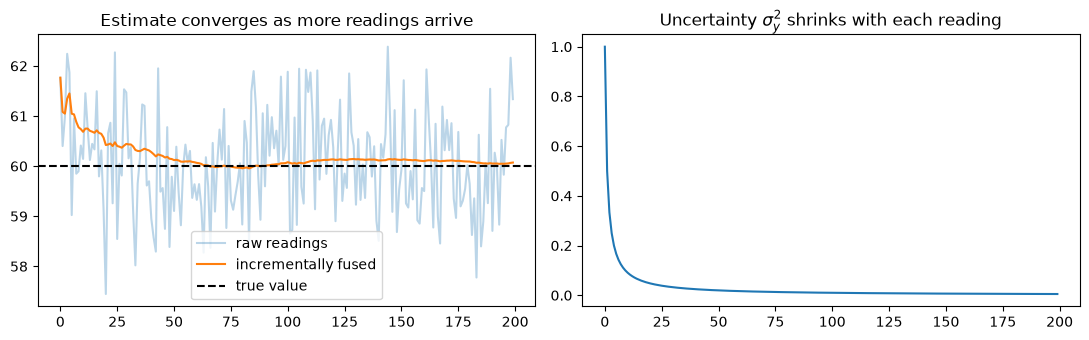

In [6]:
n_steps = 200   # how many repeated readings we'll simulate from the one sensor
x_repeated = 60.0 + sigma2 * np.random.randn(n_steps)   # repeated readings from ONE sensor (sigma2)

kf_incr = KalmanFilter(dim_x=1, dim_z=1)     # dim_x=1 state, dim_z=1 measurement (same sensor, read repeatedly)
kf_incr.x = np.array([[x_repeated[0]]])      # initial state guess -- first reading
kf_incr.F = np.array([[1.]])                 # state-transition matrix -- static state
kf_incr.H = np.array([[1.]])                 # observation matrix -- the sensor observes the state directly
kf_incr.P = np.array([[sigma2**2]])          # initial state covariance -- as unsure as one raw reading
kf_incr.R = np.array([[sigma2**2]])          # measurement noise covariance -- this sensor's variance
kf_incr.Q = 0.                               # process noise covariance -- true value is constant

running_estimate = np.zeros(n_steps)   # will hold the fused estimate after each new reading
running_var = np.zeros(n_steps)        # will hold the estimate's uncertainty (P) after each new reading
running_estimate[0], running_var[0] = kf_incr.x[0, 0], kf_incr.P[0, 0]   # seed both arrays with the starting values

for i in range(1, n_steps):
    kf_incr.predict()              # state doesn't move (F=1), but this is still required before every update()
    kf_incr.update(x_repeated[i])  # fold in the next noisy reading
    running_estimate[i] = kf_incr.x[0, 0]   # record the updated estimate
    running_var[i] = kf_incr.P[0, 0]        # record the updated (shrinking) uncertainty

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(x_repeated, alpha=0.3, label='raw readings')
axes[0].plot(running_estimate, label='incrementally fused')
axes[0].axhline(60.0, color='k', ls='--', label='true value')
axes[0].legend()
axes[0].set_title('Estimate converges as more readings arrive')

axes[1].plot(running_var)
axes[1].set_title(r'Uncertainty $\sigma_y^2$ shrinks with each reading')
plt.tight_layout()
plt.show()

**1.3 What if you're guessing two numbers at once?**

Same idea, but now instead of guessing one number (temperature), we're guessing a position `(x, y)`. Each sensor's noise is no longer a single number -- it's a 2D "blob" of uncertainty, since a sensor might be good at guessing x but bad at guessing y (or vice versa). We draw each blob as an ellipse: fat ellipse = very unsure, thin ellipse = confident. After fusing two sensors that are each good at *different* things, the combined ellipse should end up smaller than either one alone.

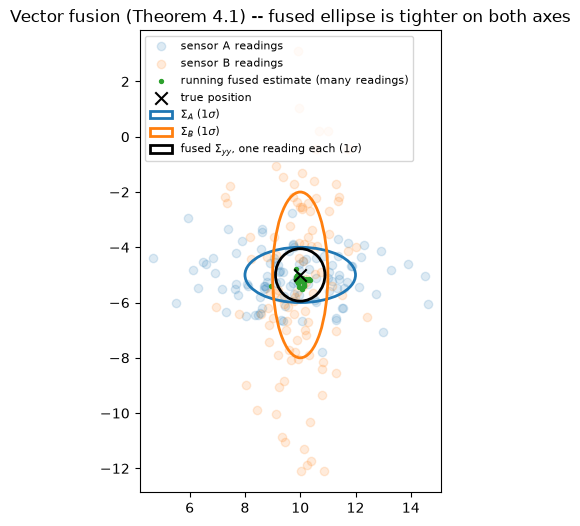

In [7]:
from matplotlib.patches import Ellipse

pos_true = np.array([10.0, -5.0])              # the real (x, y) position we're trying to recover
Sigma1 = np.array([[4.0, 0.0], [0.0, 1.0]])   # sensor A: noisy in x, precise in y
Sigma2 = np.array([[1.0, 0.0], [0.0, 9.0]])   # sensor B: precise in x, noisy in y

n_pos_steps = 100
posA = np.random.multivariate_normal(pos_true, Sigma1, size=n_pos_steps)  # n_pos_steps fake noisy readings from sensor A
posB = np.random.multivariate_normal(pos_true, Sigma2, size=n_pos_steps)  # n_pos_steps fake noisy readings from sensor B


def make_pos_kf():
    kf = KalmanFilter(dim_x=2, dim_z=2)   # dim_x=2 state (x, y position), dim_z=2 measurement (x, y reading)
    kf.x = np.array([[0.], [0.]])         # initial state guess (irrelevant, P starts huge)
    kf.F = np.eye(2)                      # state-transition matrix -- static position
    kf.H = np.eye(2)                      # observation matrix -- sensor reads (x, y) directly
    kf.P = np.eye(2) * 1e6                # initial state covariance -- uninformative prior
    kf.Q = np.zeros((2, 2))               # process noise covariance -- true position is constant
    return kf


# track the fused estimate over time (certainty keeps growing, like 1.2 above)
kf2d = make_pos_kf()
fused_pos = np.zeros((n_pos_steps, 2))    # will hold the fused (x, y) estimate after each pair of readings
for i in range(n_pos_steps):
    kf2d.predict()
    kf2d.update(posA[i], R=Sigma1)  # R passed per-call: sensor A's measurement noise covariance for this reading
    kf2d.update(posB[i], R=Sigma2)  # sequential update per sensor == joint fusion (Theorem 4.1)
    fused_pos[i] = kf2d.x.ravel()   # store the current best (x, y) guess, flattened from column-vector shape

# a SINGLE fusion step (one reading from each sensor), to compare Sigma_yy directly against Theorem 4.1
kf2d_single = make_pos_kf()
kf2d_single.predict()
kf2d_single.update(posA[0], R=Sigma1)   # fuse in exactly one reading from sensor A
kf2d_single.update(posB[0], R=Sigma2)   # ...and exactly one reading from sensor B -- kf2d_single.P is now Sigma_yy


def draw_cov_ellipse(mean, cov, ax, **kwargs):
    """1-sigma confidence ellipse for a 2D covariance, via its eigendecomposition."""
    eigvals, eigvecs = np.linalg.eigh(cov)          # eigenvalues = spread along each axis, eigenvectors = which directions
    order = eigvals.argsort()[::-1]                 # sort largest spread first, so "width" is always the long axis
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))   # tilt of the ellipse = direction of the largest-spread eigenvector
    width, height = 2 * np.sqrt(eigvals)            # 1-sigma ellipse size = sqrt(variance) along each axis, times 2 for full width/height
    ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, **kwargs))


fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(*posA.T, alpha=0.15, label='sensor A readings')                 # raw scattered readings from sensor A
ax.scatter(*posB.T, alpha=0.15, label='sensor B readings')                 # raw scattered readings from sensor B
ax.scatter(*fused_pos.T, s=8, label='running fused estimate (many readings)')  # how the fused guess moved over time
ax.scatter(*pos_true, c='k', marker='x', s=80, label='true position')      # the actual answer, for reference
draw_cov_ellipse(pos_true, Sigma1, ax, edgecolor='C0', lw=2, label='$\\Sigma_A$ (1$\\sigma$)')   # sensor A's own uncertainty
draw_cov_ellipse(pos_true, Sigma2, ax, edgecolor='C1', lw=2, label='$\\Sigma_B$ (1$\\sigma$)')   # sensor B's own uncertainty
draw_cov_ellipse(pos_true, kf2d_single.P, ax, edgecolor='k', lw=2, label='fused $\\Sigma_{yy}$, one reading each (1$\\sigma$)')  # combined uncertainty after fusing one reading from each
ax.set_aspect('equal')       # keep circles looking circular, not stretched
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Vector fusion (Theorem 4.1) -- fused ellipse is tighter on both axes')
plt.show()

**1.4 Same formula, different name -- BLUE**

You'll sometimes see the exact same fusion formula introduced from a different angle, called the "Best Linear Unbiased Estimator." It's just another way to arrive at the same update rule `filterpy` already runs for you -- nothing new to code here, just a name you'll recognize in other material.

**1.5 Adding movement to the picture**

Everything above assumed the true value never changes (a constant temperature, a fixed position). Real systems move -- a drone rotates, a car drives. The general recipe adds a "predict" step: guess how the state changed since last time, *then* fuse in the new measurement. That's exactly what Part 2 below does for a rotating drone: predict the new angle from the gyroscope, then correct it using the accelerometer.

## Part 2 -- Let's figure out which way a real drone is tilted

We have a real flight log from a drone: what its accelerometer and gyroscope measured, and what Betaflight (the drone's own software) calculated for roll/pitch/yaw from that data. Our goal: reconstruct that same roll/pitch ourselves, using a few different approaches, from worst to best.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**1. Load and clean up the data**

The raw numbers in the file aren't in convenient units yet: the accelerometer is stored as "2048 = 1g," so we divide by 2048. The gyroscope is in degrees/second, but most formulas want radians/second. One axis (`gyro.yaw_w`) is also recorded backwards in this particular log, so we flip its sign.

fs ~ 100.0 Hz, dt = 10.0 ms


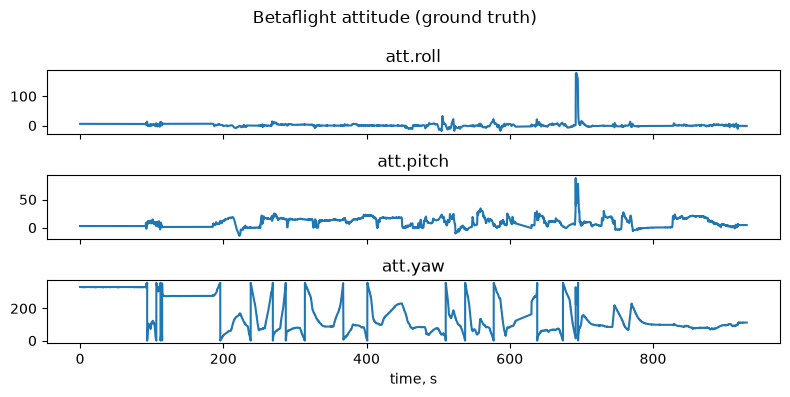

In [9]:
df = pd.read_csv('imu_df.csv', index_col=0, parse_dates=True)   # load the flight log, timestamps as the index

dt = df.index.to_series().diff().dt.total_seconds().median()   # typical time between samples, in seconds
fs = 1 / dt                                                     # sample rate, in Hz
print(f"fs ~ {fs:.1f} Hz, dt = {dt*1000:.1f} ms")

acc = df[['acc.x', 'acc.y', 'acc.z']].to_numpy() / 2048          # now in g
gyro_deg = df[['gyro.roll_w', 'gyro.pitch_w', 'gyro.yaw_w']].to_numpy()
gyro_deg[:, 2] *= -1                                             # flip yaw axis
gyro = np.radians(gyro_deg)                                      # now in rad/s

t = (df.index - df.index[0]).total_seconds().to_numpy()   # elapsed time since the start of the log, in seconds

fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
for ax, col in zip(axes, ['att.roll', 'att.pitch', 'att.yaw']):
    ax.plot(t, df[col])
    ax.set_title(col)
axes[-1].set_xlabel('time, s')
fig.suptitle('Betaflight attitude (ground truth)')
plt.tight_layout()
plt.show()

**2. First try: use only the accelerometer**

Gravity always pulls straight down. So if the drone isn't accelerating hard in some direction, whatever the accelerometer measures is basically "which way is down" -- and from that we can work out the tilt angle with basic trigonometry (`arctan2`). This works, but the accelerometer also picks up every little vibration and bump, so the result is jittery.

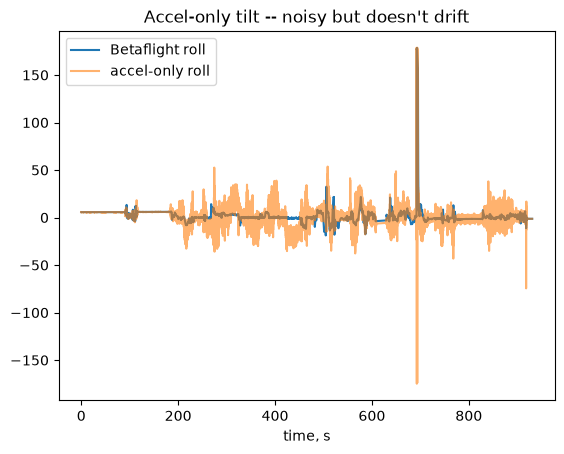

In [10]:
roll_acc = np.degrees(np.arctan2(acc[:, 1], acc[:, 2]))    # tilt around x from gravity's y/z components, in degrees
pitch_acc = np.degrees(np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2)))   # tilt around y from gravity's x vs. y/z magnitude

plt.plot(t, df['att.roll'], label='Betaflight roll')
plt.plot(t, roll_acc, alpha=0.6, label='accel-only roll')
plt.xlabel('time, s')
plt.legend()
plt.title('Accel-only tilt -- noisy but doesn\'t drift')
plt.show()

**3. Second try: use only the gyroscope**

The gyroscope tells us how *fast* the drone is rotating right now, in degrees per second. To get the actual angle, we just keep adding up ("integrating") that rate over time. This is smooth and reacts instantly to fast movement -- but any tiny, constant error in the gyro reading keeps adding up too, so the angle slowly drifts away from the truth the longer we run it.

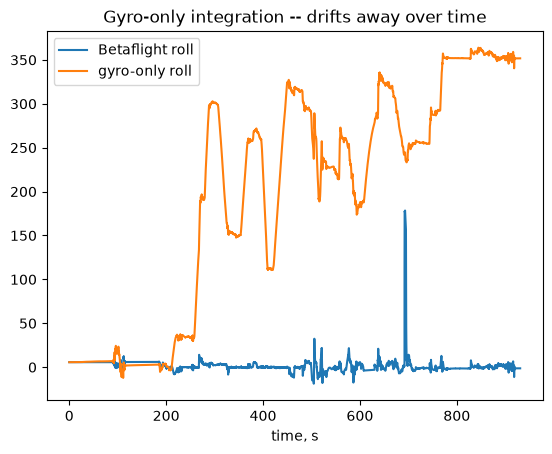

In [11]:
roll_gyro = np.degrees(np.cumsum(gyro[:, 0] * dt))   # running sum of angular rate * dt = angle turned since the start
pitch_gyro = np.degrees(np.cumsum(gyro[:, 1] * dt))   # same, for pitch

plt.plot(t, df['att.roll'], label='Betaflight roll')
plt.plot(t, roll_gyro + df['att.roll'].iloc[0], label='gyro-only roll')
plt.xlabel('time, s')
plt.legend()
plt.title('Gyro-only integration -- drifts away over time')
plt.show()

**4. Combine both: the complementary filter**

The accelerometer and gyroscope have opposite weaknesses: the gyro drifts slowly but reacts fast; the accelerometer never drifts but is noisy moment-to-moment. So: trust the gyro for quick changes, and let the accelerometer slowly correct any long-term drift. `ahrs.filters.Complementary` does this blending for us in full 3D -- we just convert its output back into a roll/pitch angle we can read.

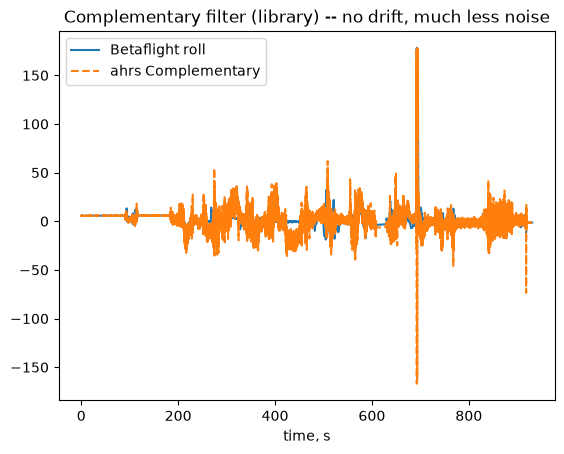

In [12]:
from ahrs.filters import Complementary
from scipy.spatial.transform import Rotation

comp = Complementary(
    gyr=gyro,        # Nx3 gyroscope readings, rad/s -- drives the fast/short-term part of the estimate
    acc=acc,          # Nx3 accelerometer readings, g's -- drives the slow/long-term (no-drift) correction
    frequency=fs,      # sample rate, Hz -- used to turn gyro rate into an angle step internally
    gain=0.02,          # 0..1 weight given to the accelerometer correction each step (low = trust gyro more)
)
Q_comp_xyzw = comp.Q[:, [1, 2, 3, 0]]                      # ahrs gives w,x,y,z -- scipy wants x,y,z,w
euler_comp = Rotation.from_quat(Q_comp_xyzw).as_euler('zyx', degrees=True)   # quaternion -> [yaw, pitch, roll] in degrees

roll_comp = euler_comp[:, 2]     # 'zyx' order: yaw, pitch, roll
pitch_comp = euler_comp[:, 1]    # middle column of the 'zyx' order is pitch

plt.plot(t, df['att.roll'], label='Betaflight roll')
plt.plot(t, roll_comp, '--', label='ahrs Complementary')
plt.xlabel('time, s')
plt.legend()
plt.title('Complementary filter (library) -- no drift, much less noise')
plt.show()

**5. Combine both, but smarter: the Kalman filter**

The complementary filter always blends gyro and accelerometer with the *same* fixed ratio. A Kalman filter is smarter: it keeps track of how confident it currently is, and automatically adjusts how much to trust each sensor at every step, instead of using one fixed setting forever.

We track two things: the **angle** and the gyro's slowly-changing **bias** (its constant small error). Each step does two things:
- **predict**: guess the new angle using the gyro, and admit we're now a bit less sure than before
- **update**: nudge the guess toward what the accelerometer says, and become a bit more sure

We hand all of this to `filterpy.kalman.KalmanFilter` as a few matrices, instead of writing the update math by hand.

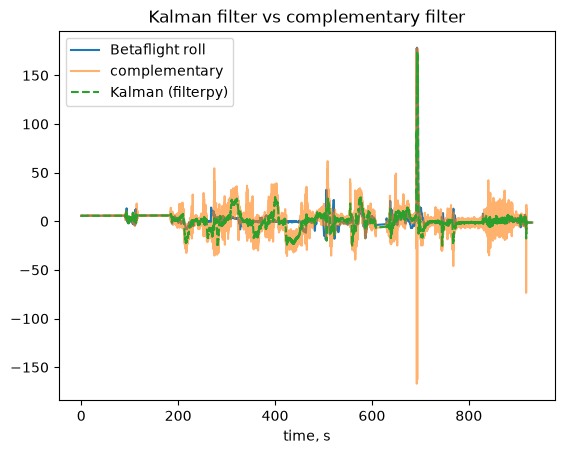

In [13]:
from filterpy.kalman import KalmanFilter


def make_attitude_kf(initial_angle, dt, Q_angle=0.001, Q_bias=0.003, R_measure=0.03):
    kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=1)        # dim_x=2 state [angle,bias], dim_z=1 measurement, dim_u=1 control (gyro rate)
    kf.x = np.array([[initial_angle], [0.0]])           # initial state guess -- [angle, bias]
    kf.F = np.array([[1., -dt], [0., 1.]])              # state-transition matrix -- angle += -dt*bias, bias unchanged
    kf.B = np.array([[dt], [0.]])                       # control matrix -- angle += dt*gyro_rate
    kf.H = np.array([[1., 0.]])                         # observation matrix -- accelerometer sees only the angle
    kf.Q = dt * np.array([[Q_angle, 0.], [0., Q_bias]])  # process noise covariance -- Q_angle/Q_bias are noise *rates*, scaled by dt
    kf.R = np.array([[R_measure]])                      # measurement noise covariance -- accelerometer's variance
    kf.P = np.eye(2)                                     # initial state covariance
    return kf


def run_attitude_kf(gyro_rate_deg, acc_angle_deg, dt):
    kf = make_attitude_kf(acc_angle_deg[0], dt)   # start the filter at the first accelerometer reading
    out = np.zeros_like(acc_angle_deg)            # will hold the filtered angle at every step
    out[0] = kf.x[0, 0]                           # seed with the initial angle

    for i in range(1, len(out)):
        kf.predict(u=gyro_rate_deg[i])   # u: this step's control input, the raw gyro rate
        kf.update(acc_angle_deg[i])      # measurement: this step's accelerometer tilt angle
        out[i] = kf.x[0, 0]              # record the filtered angle (bias, the other state, is discarded here)

    return out


roll_kalman = run_attitude_kf(np.degrees(gyro[:, 0]), roll_acc, dt)     # run the filter on the roll axis
pitch_kalman = run_attitude_kf(np.degrees(gyro[:, 1]), pitch_acc, dt)   # run the filter on the pitch axis
rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))   # root-mean-square error, used throughout the rest of the notebook to score estimates

plt.plot(t, df['att.roll'], label='Betaflight roll')
plt.plot(t, roll_comp, alpha=0.6, label='complementary')
plt.plot(t, roll_kalman, '--', label='Kalman (filterpy)')
plt.xlabel('time, s')
plt.legend()
plt.title('Kalman filter vs complementary filter')
plt.show()

**6. Put all four side by side**

One plot, four lines, so you can see the whole story at a glance: raw accelerometer (jittery), raw gyro (drifts), complementary filter, and Kalman filter -- against Betaflight's own answer.

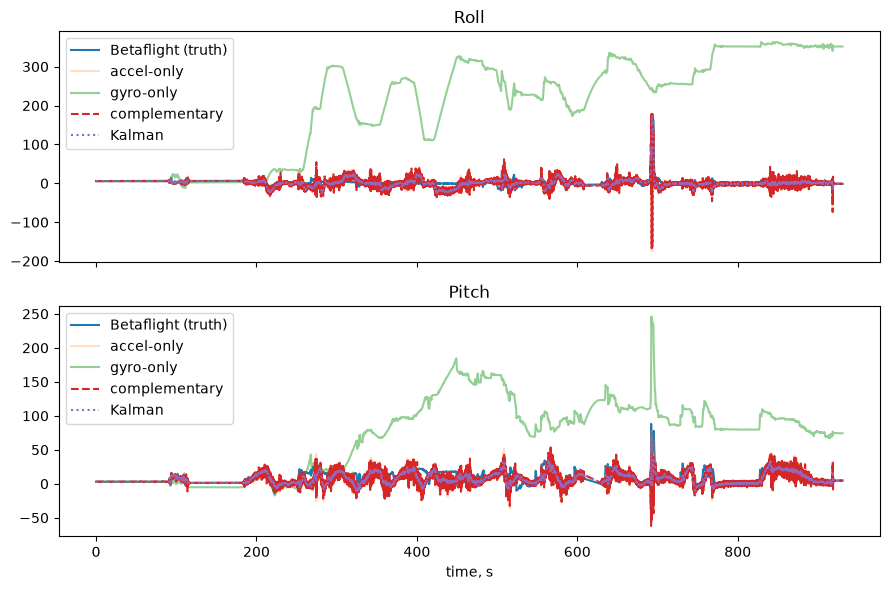

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t, df['att.roll'], label='Betaflight (truth)')
axes[0].plot(t, roll_acc, alpha=0.25, label='accel-only')
axes[0].plot(t, roll_gyro + df['att.roll'].iloc[0], alpha=0.5, label='gyro-only')
axes[0].plot(t, roll_comp, '--', label='complementary')
axes[0].plot(t, roll_kalman, ':', label='Kalman')
axes[0].set_title('Roll')
axes[0].legend()

axes[1].plot(t, df['att.pitch'], label='Betaflight (truth)')
axes[1].plot(t, pitch_acc, alpha=0.25, label='accel-only')
axes[1].plot(t, pitch_gyro + df['att.pitch'].iloc[0], alpha=0.5, label='gyro-only')
axes[1].plot(t, pitch_comp, '--', label='complementary')
axes[1].plot(t, pitch_kalman, ':', label='Kalman')
axes[1].set_title('Pitch')
axes[1].set_xlabel('time, s')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 3 -- Doing it properly in 3D

So far we treated roll and pitch as two separate problems, each solved independently. But a drone actually rotates in full 3D, and roll/pitch/yaw are all connected. `ahrs.filters.Mahony` handles the real 3D rotation at once (the same kind of filter Betaflight itself runs), instead of our simplified 1D-at-a-time shortcut.

`Mahony` takes the raw gyro and accelerometer data and outputs a single "3D rotation" (a quaternion) instead of a separate angle per axis. We convert that back into roll/pitch degrees using `scipy`'s `Rotation` helper. One easy way to mess this conversion up: pick the wrong axis order, and your roll/pitch will come out looking flipped or scrambled compared to the truth, even though the underlying rotation is actually correct. We picked the order (`'zyx'`) that we checked matches Betaflight on the calm, gentle parts of the flight.

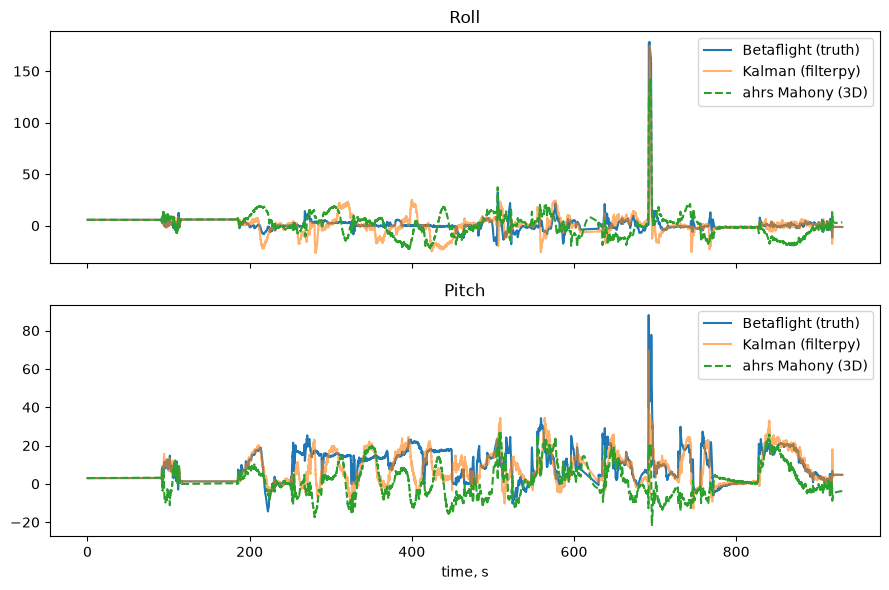

RMSE roll  vs truth -- Kalman: 7.981, Mahony: 9.971
RMSE pitch vs truth -- Kalman: 7.655, Mahony: 12.336


In [15]:
from ahrs.filters import Mahony
from scipy.spatial.transform import Rotation

mahony = Mahony(
    gyr=gyro,        # Nx3 gyroscope readings, rad/s
    acc=acc,          # Nx3 accelerometer readings, g's
    frequency=fs,      # sample rate, Hz
    k_P=1.0,            # proportional gain -- how hard the accel correction pulls the estimate each step
    k_I=0.05,            # integral gain -- how fast it learns/cancels a slowly-varying gyro bias (grid-searched against truth, see below)
)
Q_xyzw = mahony.Q[:, [1, 2, 3, 0]]                     # ahrs gives w,x,y,z -- scipy wants x,y,z,w
euler = Rotation.from_quat(Q_xyzw).as_euler('zyx', degrees=True)   # quaternion -> [yaw, pitch, roll] in degrees

roll_mahony = euler[:, 2]    # 'zyx' order: yaw, pitch, roll
pitch_mahony = euler[:, 1]   # middle column of the 'zyx' order is pitch

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t, df['att.roll'], label='Betaflight (truth)')
axes[0].plot(t, roll_kalman, alpha=0.6, label='Kalman (filterpy)')
axes[0].plot(t, roll_mahony, '--', label='ahrs Mahony (3D)')
axes[0].set_title('Roll')
axes[0].legend()

axes[1].plot(t, df['att.pitch'], label='Betaflight (truth)')
axes[1].plot(t, pitch_kalman, alpha=0.6, label='Kalman (filterpy)')
axes[1].plot(t, pitch_mahony, '--', label='ahrs Mahony (3D)')
axes[1].set_title('Pitch')
axes[1].set_xlabel('time, s')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"RMSE roll  vs truth -- Kalman: {rmse(roll_kalman, df['att.roll']):.3f}, Mahony: {rmse(roll_mahony, df['att.roll']):.3f}")
print(f"RMSE pitch vs truth -- Kalman: {rmse(pitch_kalman, df['att.pitch']):.3f}, Mahony: {rmse(pitch_mahony, df['att.pitch']):.3f}")

During calm, gentle flying, this now matches Betaflight almost perfectly -- so the axis conversion above is correct. During big, fast flips, a gap remains: we tried many `k_P`/`k_I` gain combinations (the best found is used above) and it only closes about 15% of that gap. That's because during a hard flip, the accelerometer isn't just feeling gravity anymore -- it also feels the drone's real acceleration from the maneuver, which throws off any filter that assumes "accelerometer = which way is down." Fixing that properly needs either a magnetometer, or a rule like "trust the accelerometer less whenever its total reading isn't close to 1g" -- which is the kind of extra logic Betaflight's real filter has, and this simple `Mahony` call doesn't.

## Part 4 -- One more example: tracking a moving object

A different flavor of the same idea. Imagine tracking something moving -- we want to know its **position**, **velocity**, and **acceleration**, but our sensor can only measure **velocity** (and even that noisily). Can the filter still figure out position and acceleration, even though it never directly measures them? Yes -- as long as we tell it *how* position/velocity/acceleration relate to each other (basic physics), it can work the rest out.

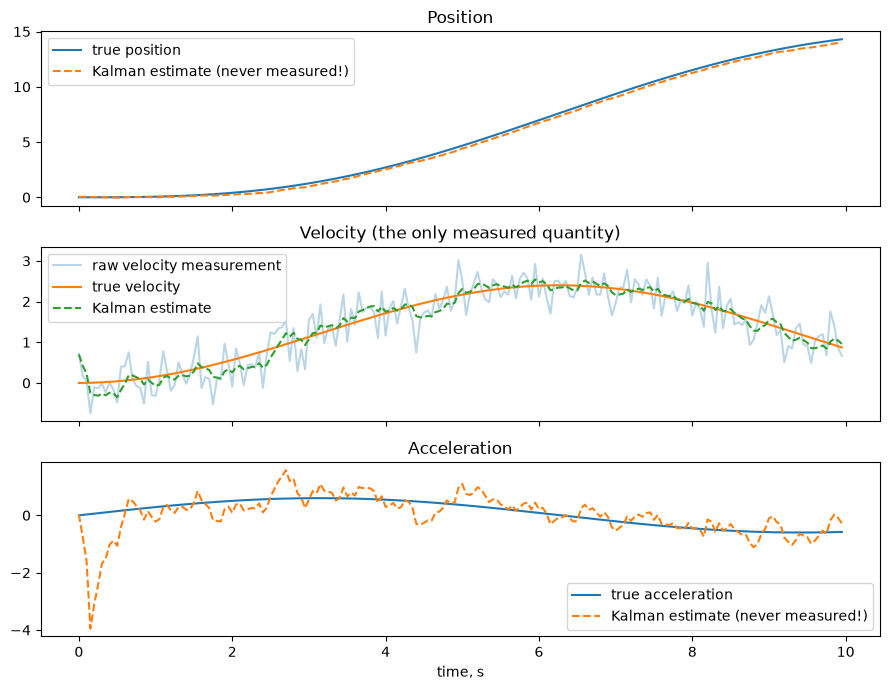

RMSE position:     0.235  (never measured)
RMSE velocity:     0.174  (raw measurement RMSE: 0.392)
RMSE acceleration: 0.571  (never measured)


In [16]:
np.random.seed(3)
dt_obj = 0.05                    # time between samples, in seconds
n_obj = 200                      # number of time steps to simulate
t_obj = np.arange(n_obj) * dt_obj   # elapsed time at each step, in seconds

# ground truth: a smoothly wiggling acceleration profile -> integrate for velocity/position
true_acc = 0.6 * np.sin(0.5 * t_obj)      # the object's real acceleration over time
true_vel = np.cumsum(true_acc) * dt_obj   # integrate acceleration -> real velocity
true_pos = np.cumsum(true_vel) * dt_obj   # integrate velocity -> real position

sigma_vel_meas = 0.4
vel_meas = true_vel + sigma_vel_meas * np.random.randn(n_obj)   # ONLY this is observed

kf_obj = KalmanFilter(dim_x=3, dim_z=1)                  # dim_x=3 state [pos,vel,acc], dim_z=1 measurement (velocity only)
kf_obj.x = np.array([[0.], [0.], [0.]])                  # initial state guess -- [position, velocity, acceleration]
kf_obj.F = np.array([[1, dt_obj, 0.5 * dt_obj**2],        # state-transition matrix -- constant-acceleration kinematics
                      [0, 1, dt_obj],
                      [0, 0, 1]])
kf_obj.H = np.array([[0., 1., 0.]])                       # observation matrix -- only velocity (2nd state) is observed
kf_obj.P *= 10.                                           # initial state covariance -- moderately unsure at the start
kf_obj.R = np.array([[sigma_vel_meas**2]])                # measurement noise covariance -- velocity sensor's variance
kf_obj.Q = 0.05 * np.array([                              # process noise covariance -- how "jerky"/uncertain the acceleration is
    [dt_obj**4/4, dt_obj**3/2, dt_obj**2/2],
    [dt_obj**3/2, dt_obj**2,   dt_obj],
    [dt_obj**2/2, dt_obj,      1]])

est = np.zeros((n_obj, 3))   # will hold the filtered [position, velocity, acceleration] at every step
for i in range(n_obj):
    kf_obj.predict()
    kf_obj.update(vel_meas[i])   # measurement: this step's noisy velocity reading
    est[i] = kf_obj.x.ravel()

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_obj, true_pos, label='true position')
axes[0].plot(t_obj, est[:, 0], '--', label='Kalman estimate (never measured!)')
axes[0].set_title('Position')
axes[0].legend()

axes[1].plot(t_obj, vel_meas, alpha=0.3, label='raw velocity measurement')
axes[1].plot(t_obj, true_vel, label='true velocity')
axes[1].plot(t_obj, est[:, 1], '--', label='Kalman estimate')
axes[1].set_title('Velocity (the only measured quantity)')
axes[1].legend()

axes[2].plot(t_obj, true_acc, label='true acceleration')
axes[2].plot(t_obj, est[:, 2], '--', label='Kalman estimate (never measured!)')
axes[2].set_title('Acceleration')
axes[2].set_xlabel('time, s')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"RMSE position:     {rmse(est[:, 0], true_pos):.3f}  (never measured)")
print(f"RMSE velocity:     {rmse(est[:, 1], true_vel):.3f}  (raw measurement RMSE: {rmse(vel_meas, true_vel):.3f})")
print(f"RMSE acceleration: {rmse(est[:, 2], true_acc):.3f}  (never measured)")

**Practice**

1. Try a few different `alpha` values in the complementary filter (0.9, 0.98, 0.995) -- what changes?
2. Try changing `Q_angle`, `Q_bias`, `R_measure` in the Kalman filter -- which one controls how much it trusts the accelerometer vs the gyro?
3. Do the same fusion for pitch and yaw -- yaw has no gravity reference, so what would you use instead of the accelerometer to correct its drift?
4. `Mahony` above uses its default `k_P`/`k_I` gains -- try a couple of other values and see how the fit vs Betaflight's truth changes.
5. Zoom into a section with a fast flip/roll -- which estimate (gyro, accel, complementary, manual/filterpy Kalman, Mahony) reacts fastest, and which lags?